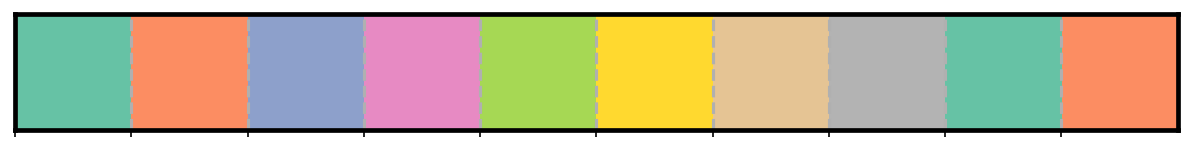

In [4]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import pandas as pd
from iminuit import Minuit
from scipy import stats
from iminuit import cost
from scipy import integrate
import scipy
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.model_selection import RandomizedSearchCV


def setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150):
    """
    Global plotting setup with grey background and custom styling
    """

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    # --- Background color ---
    plt.rcParams['axes.facecolor'] = "#e8e8e8"

    # --- Fonts ---
    rc = {"font.family": "serif", 
          "mathtext.fontset": "stix"}
    plt.rcParams.update(rc)
    plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
    
    plt.rcParams.update({
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Color palette ---
    colors = sns.color_palette("Set2", 10)
    sns.set_palette(colors)
    sns.palplot(colors)
    plt.show()

    return colors




def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)
colors = setup_plotting(ticksize=18, fontsize=30, figsize=(16, 9), dpi=150)

In [15]:
def uniform_on_sphere(npoints):

    phi = np.random.uniform(0, 2 * np.pi, npoints)
    costheta = np.random.uniform(-1, 1, npoints)
    theta = np.arccos(costheta)
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return x, y , z, theta, phi



(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

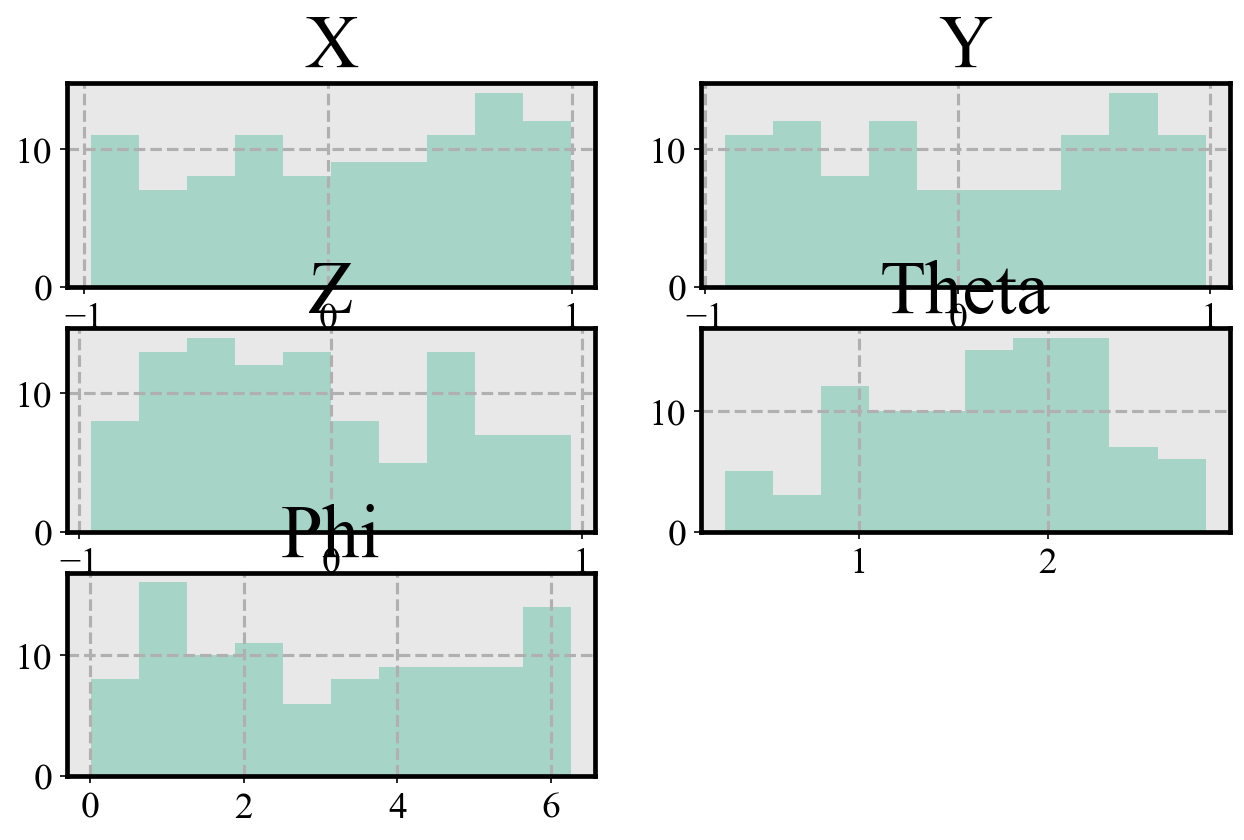

In [40]:
x,y,z,theta,phi = uniform_on_sphere(100)
fig, ax = plt.subplots(3, 2, figsize=(10, 6))
ax[0,0].hist(x, alpha=0.5)
ax[0,0].set_title('X')
ax[0,1].hist(y, alpha=0.5)
ax[0,1].set_title('Y')
ax[1,0].hist(z, alpha=0.5)
ax[1,0].set_title('Z')
ax[1,1].hist(theta, alpha=0.5)
ax[1,1].set_title('Theta')
ax[2,0].hist(phi, alpha=0.5)
ax[2,0].set_title('Phi')
ax[2,1].axis('off')

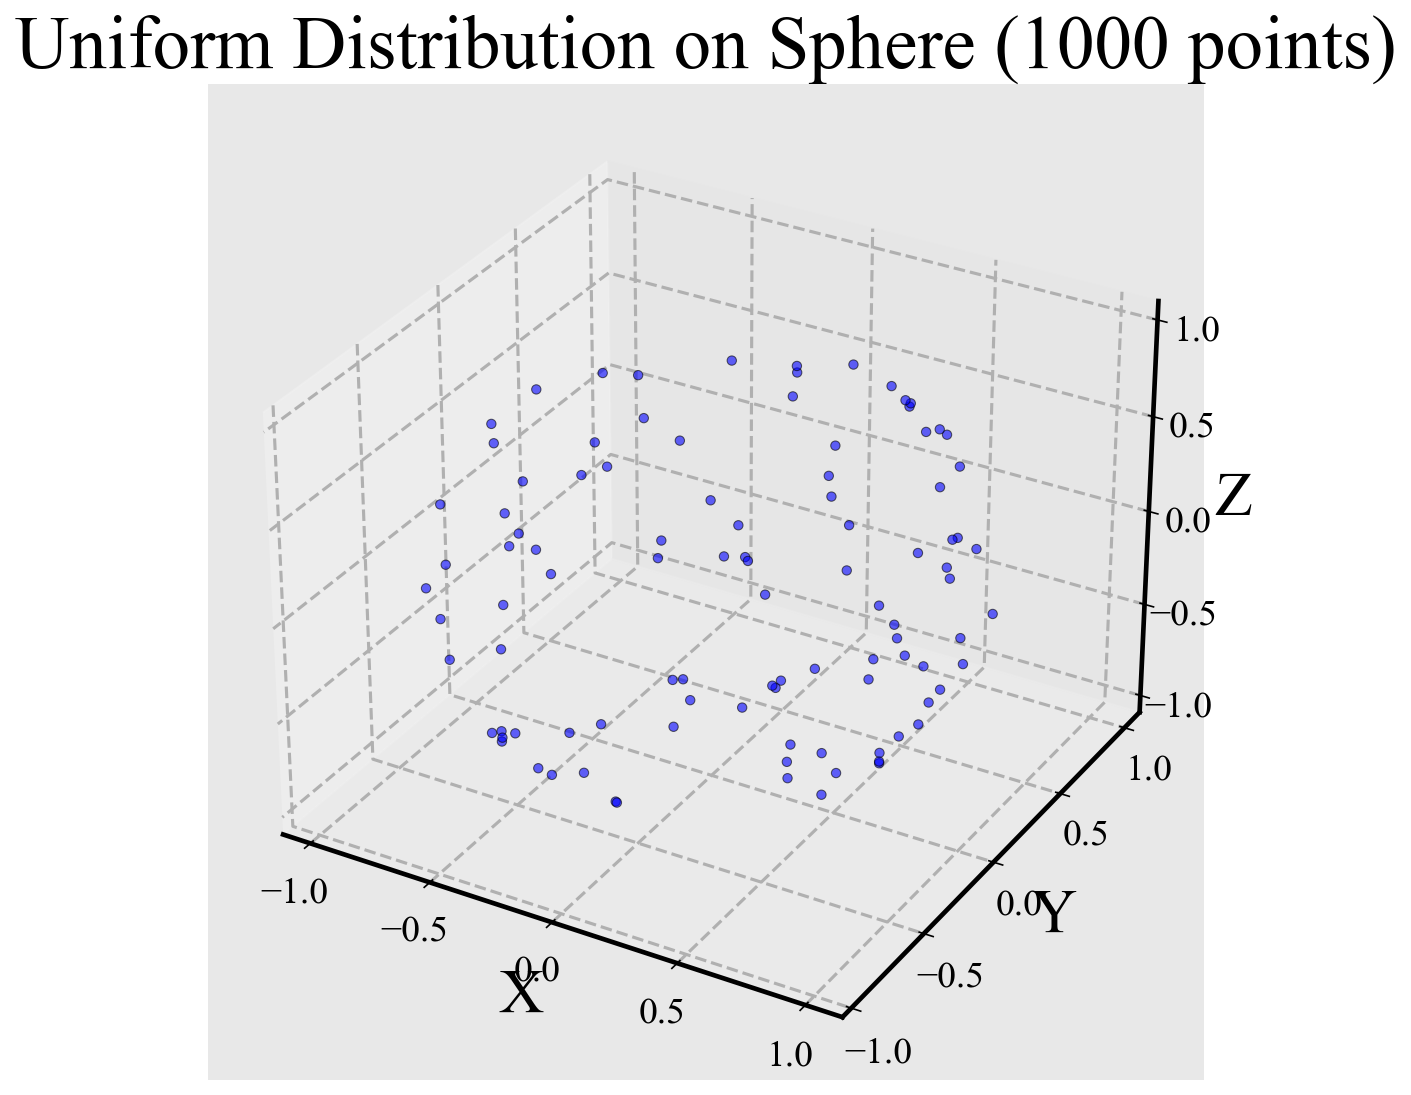

In [41]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, alpha=0.6, s=20, c='blue', edgecolors='black', linewidth=0.5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Uniform Distribution on Sphere (1000 points)')

plt.tight_layout()
plt.show()

In [44]:
def angular_distance(point1, point2):


    # Calculate the angular distance using the spherical law of cosines
    #cos_angle = (np.sin(theta1) * np.sin(theta2) * np.cos(phi1 - phi2) +
    #             np.cos(theta1) * np.cos(theta2))
    cos_angle = np.dot(point1, point2) # Dot product of the two vectors
    # Ensure the cosine value is within the valid range [-1, 1] to avoid numerical issues
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    
    #angle = np.arccos(cos_angle)
    
    return cos_angle

def cum_two_point_aut_corr(points, max_angle):
    Npoints = points.shape[0]
    C = 0
    for i in range(Npoints):
        for j in range(i+1, Npoints):
            dist = angular_distance(points[i], points[j])
            if dist >= max_angle:
                C+=1
            
    C*=2/(Npoints*(Npoints-1))
    
    return C

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/var/folders/t0/dsmc290j5355qf2rn298qwb40000gn/T/ipykernel_19846/2723327524.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('$cos(\phi)$')
/var/folders/t0/dsmc290j5355qf2rn298qwb40000gn/T/ipykernel_19846/2723327524.py:12: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('C($cos(\phi)$)')


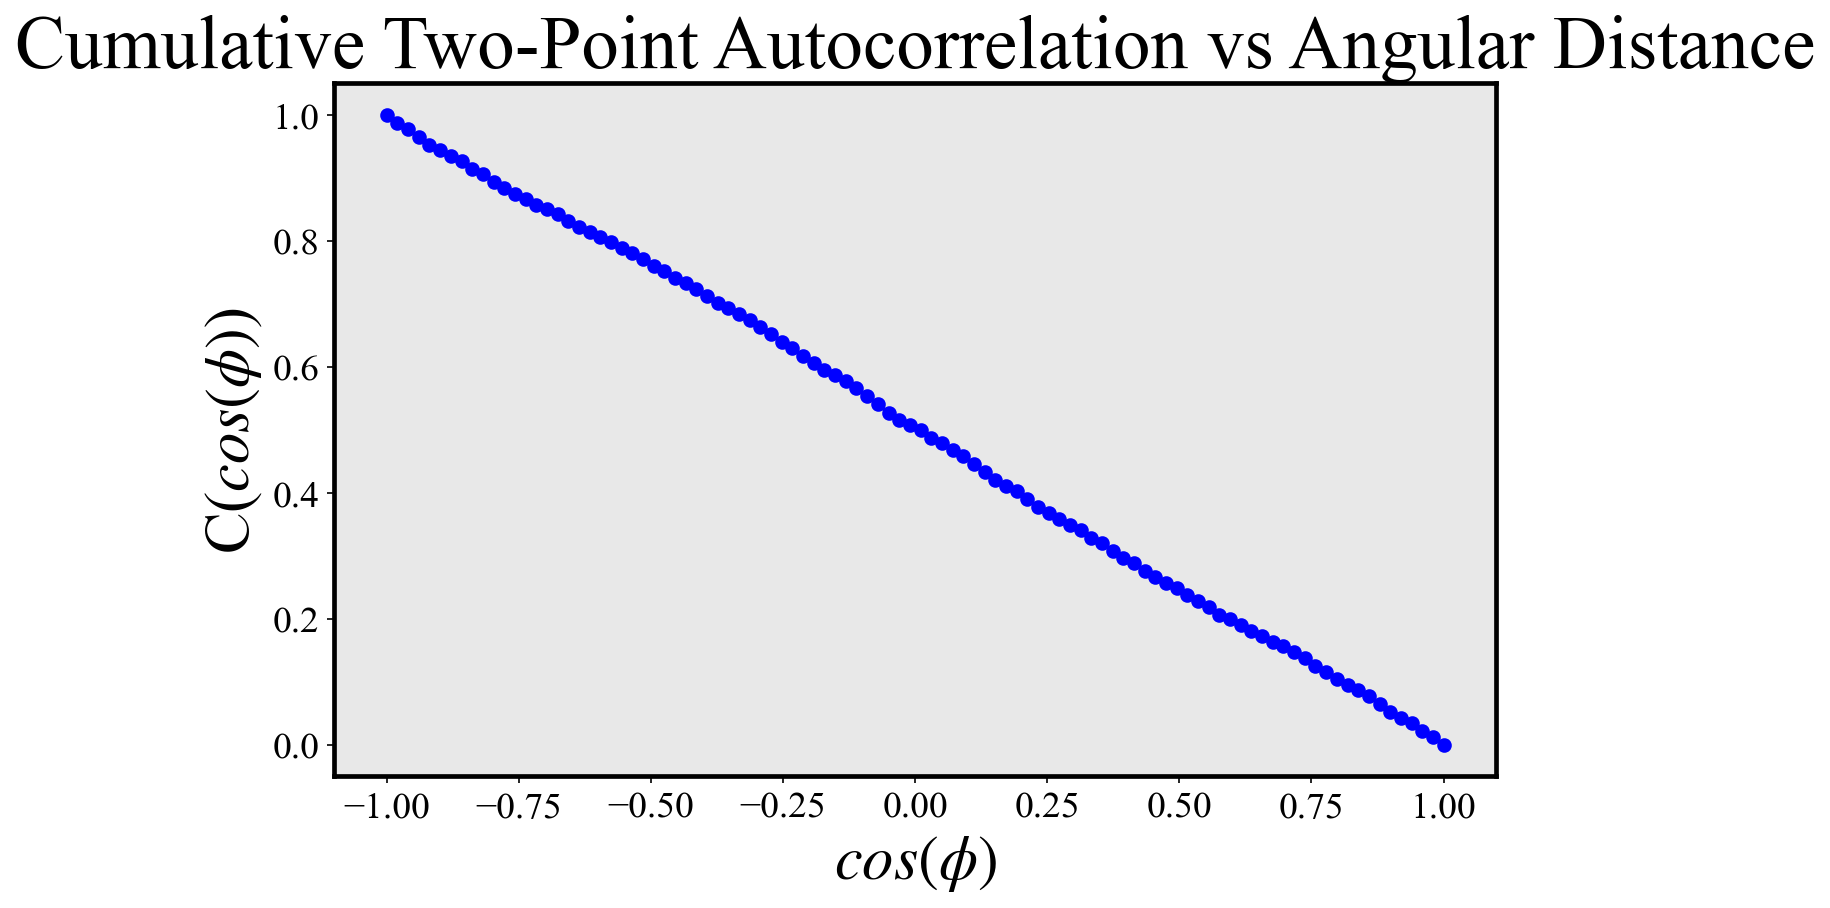

In [45]:
angles = np.linspace(-1, 1, 100)
points = np.array([x,y,z]).T

cum_corr = []
for angle in angles:
    C = cum_two_point_aut_corr(points, angle)
    cum_corr.append(C)

plt.figure(figsize=(10, 6))
plt.plot(angles, cum_corr, marker='o', linestyle='-', color='blue')
plt.xlabel('$cos(\phi)$')
plt.ylabel('C($cos(\phi)$)')
plt.title('Cumulative Two-Point Autocorrelation vs Angular Distance')
plt.grid()

In [46]:
def non_uniform_on_sphere(npoints):

    phi = np.random.uniform(0, 2 * np.pi, npoints)
    theta = np.random.uniform(-np.pi, np.pi, npoints)
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return x, y , z, theta, phi

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

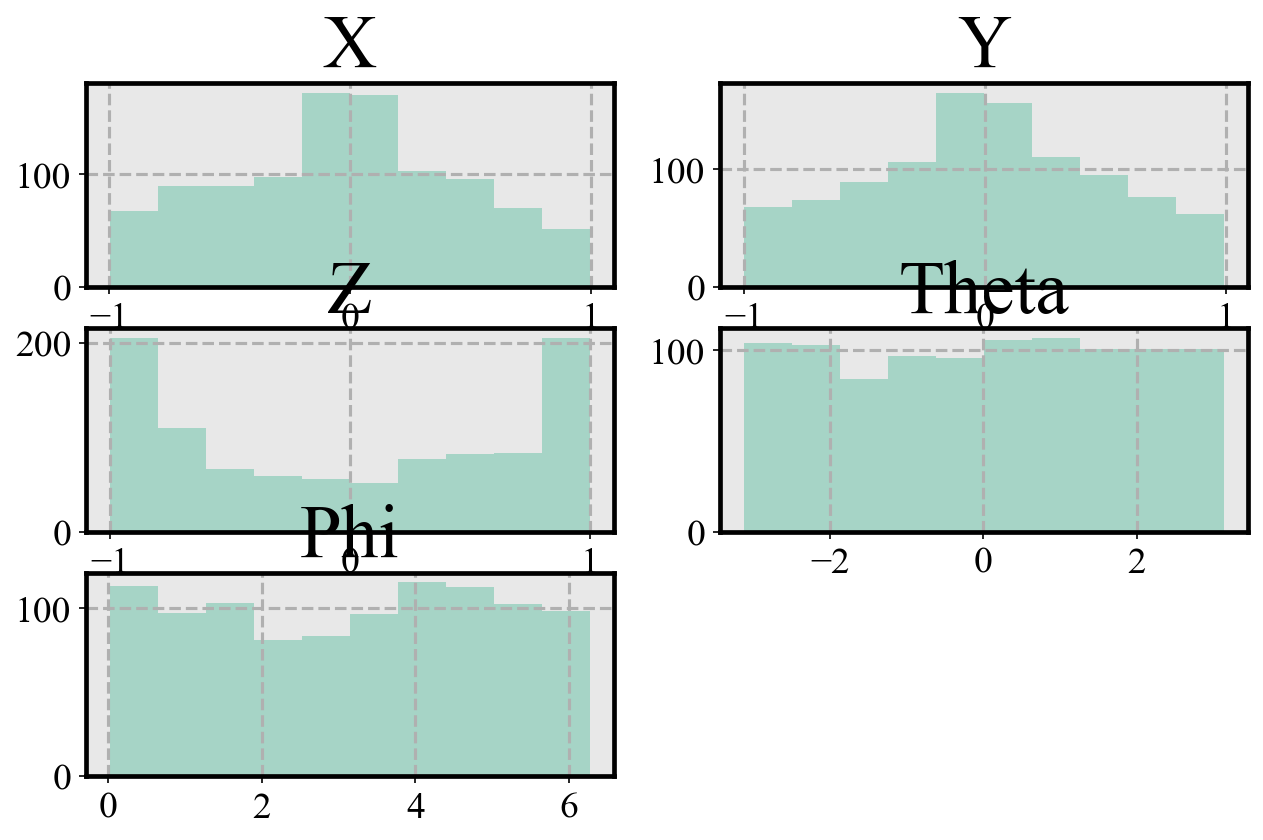

In [51]:
x,y,z,theta,phi = non_uniform_on_sphere(1000)
fig, ax = plt.subplots(3, 2, figsize=(10, 6))
ax[0,0].hist(x, alpha=0.5)
ax[0,0].set_title('X')
ax[0,1].hist(y, alpha=0.5)
ax[0,1].set_title('Y')
ax[1,0].hist(z, alpha=0.5)
ax[1,0].set_title('Z')
ax[1,1].hist(theta, alpha=0.5)
ax[1,1].set_title('Theta')
ax[2,0].hist(phi, alpha=0.5)
ax[2,0].set_title('Phi')
ax[2,1].axis('off')


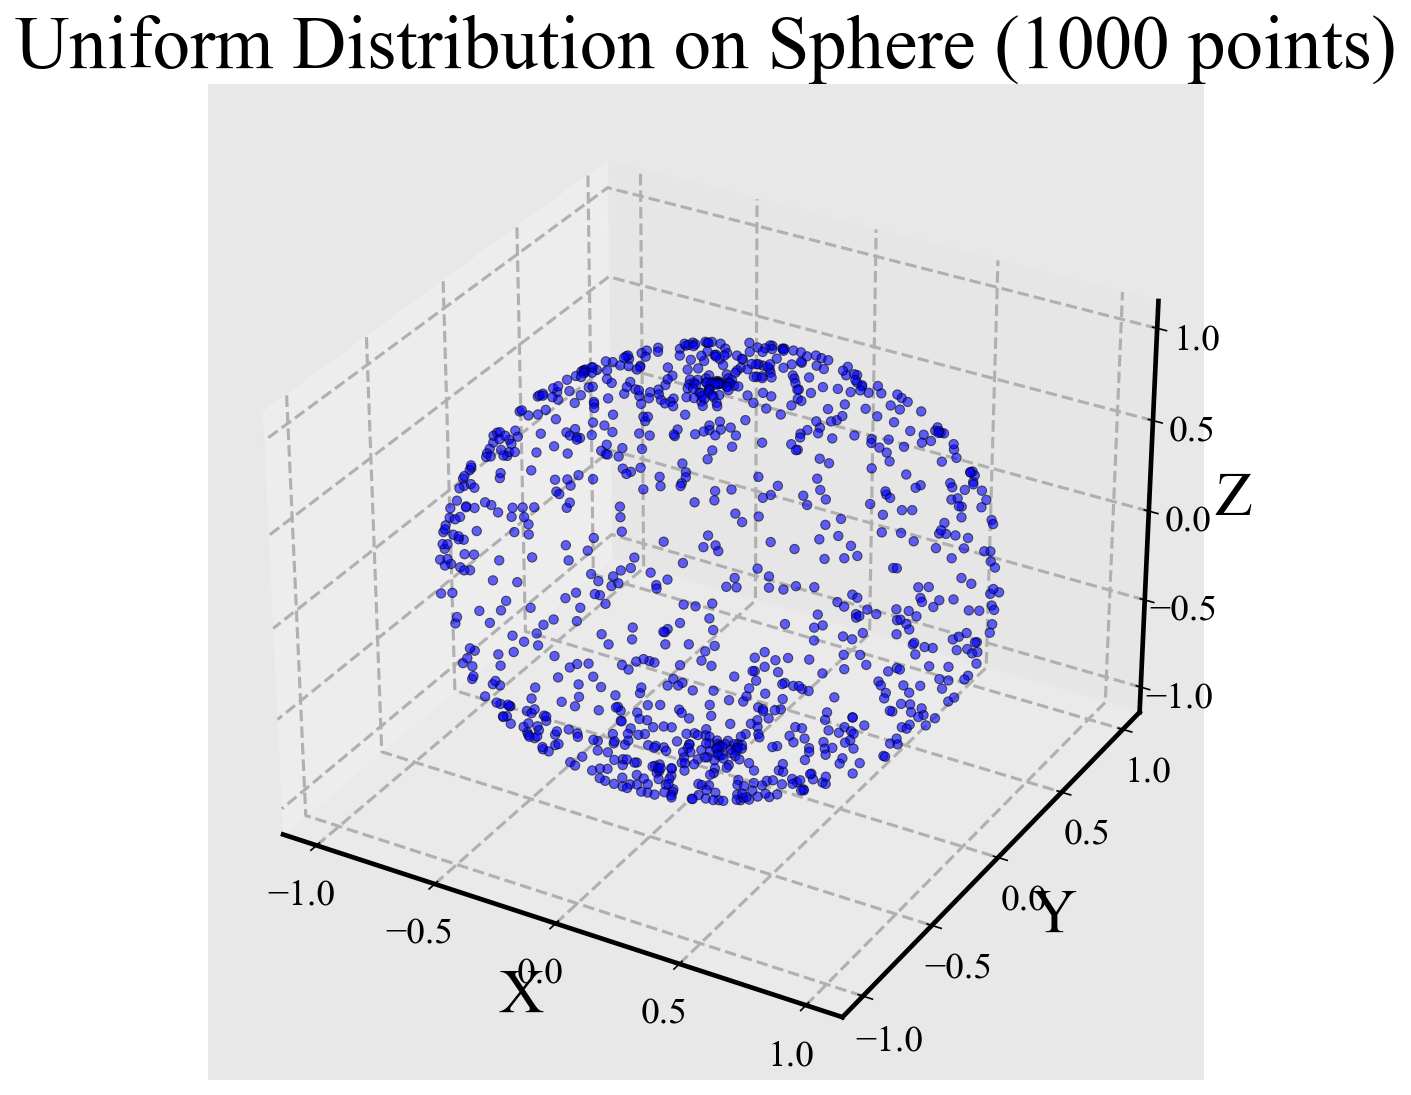

In [52]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, alpha=0.6, s=20, c='blue', edgecolors='black', linewidth=0.5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Uniform Distribution on Sphere (1000 points)')

plt.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/var/folders/t0/dsmc290j5355qf2rn298qwb40000gn/T/ipykernel_19846/2723327524.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('$cos(\phi)$')
/var/folders/t0/dsmc290j5355qf2rn298qwb40000gn/T/ipykernel_19846/2723327524.py:12: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('C($cos(\phi)$)')


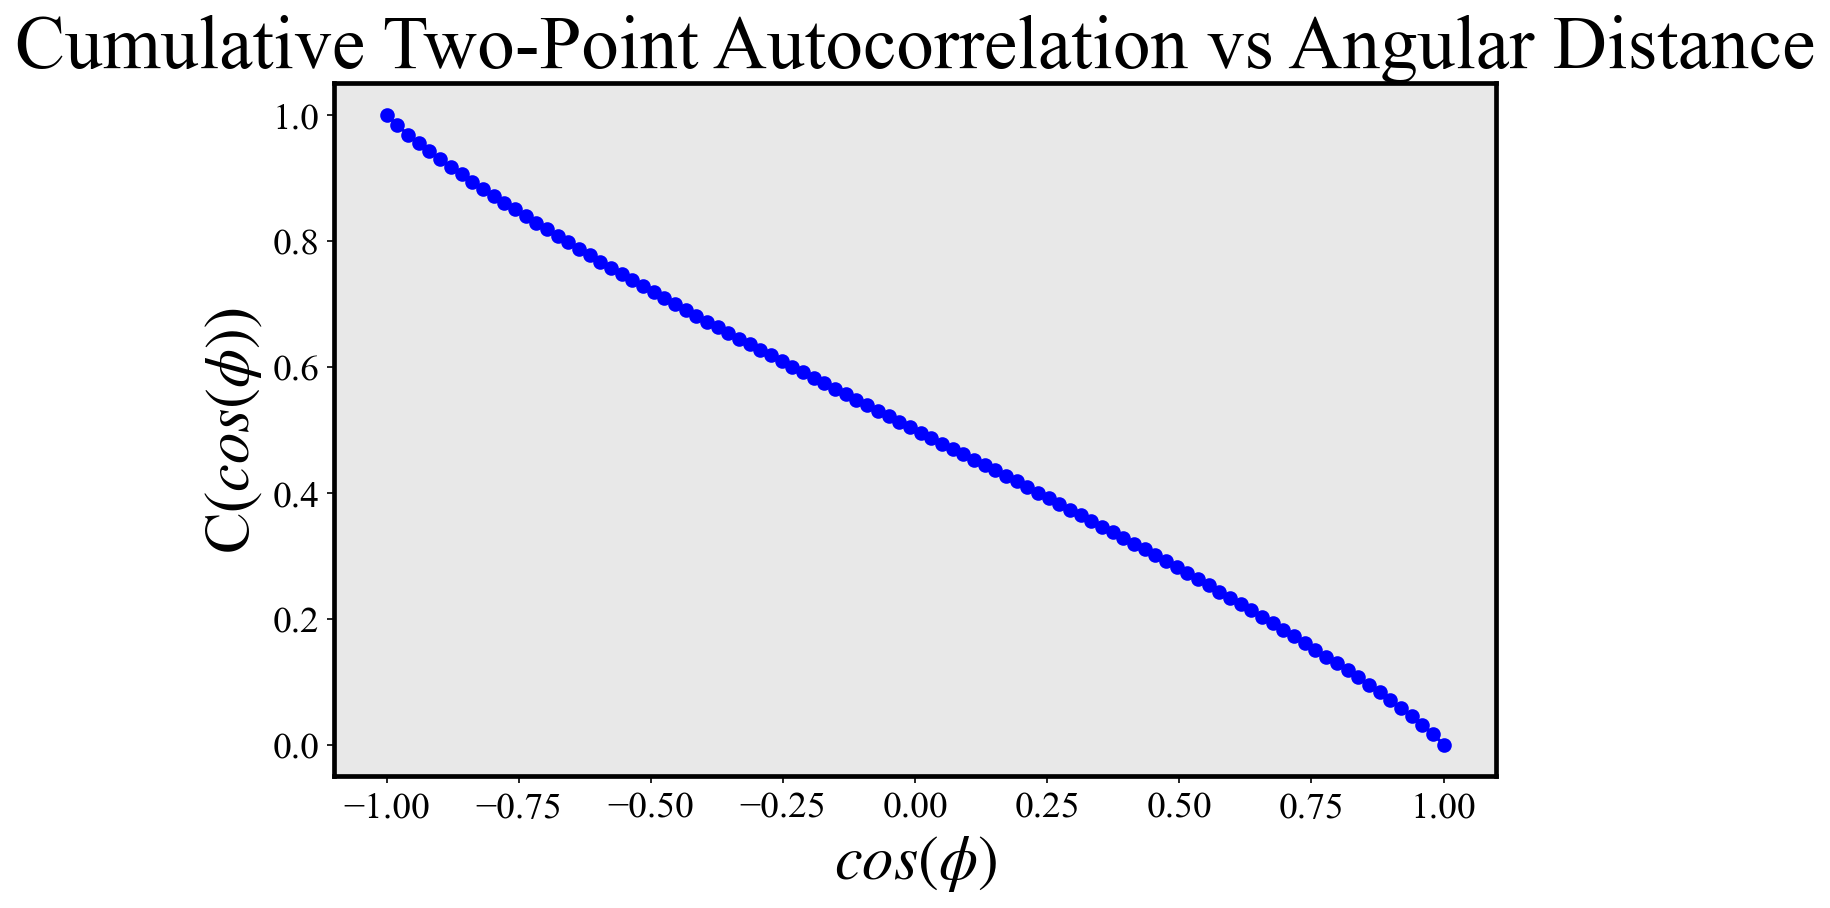

In [53]:
angles = np.linspace(-1, 1, 100)
points = np.array([x,y,z]).T

cum_corr = []
for angle in angles:
    C = cum_two_point_aut_corr(points, angle)
    cum_corr.append(C)

plt.figure(figsize=(10, 6))
plt.plot(angles, cum_corr, marker='o', linestyle='-', color='blue')
plt.xlabel('$cos(\phi)$')
plt.ylabel('C($cos(\phi)$)')
plt.title('Cumulative Two-Point Autocorrelation vs Angular Distance')
plt.grid()